# Marketing Analytics — Campaign Performance

**Dataset:** [iFood Marketing Data — Kaggle](https://www.kaggle.com/datasets/jackdaoud/marketing-data)

---

## Objective

This analysis explores a marketing dataset containing records for 2,206 customers of a food delivery company. The goal is to understand who these customers are, which product categories drive the most revenue, how each of the five targeted campaigns has performed, and which purchase channels — web, store, catalog, or deal-based — are most effective at converting engagement into transactions. The findings are intended to support decisions around campaign targeting, segment prioritization, and channel investment.

## Data

The dataset is a single CSV file capturing both demographic and behavioral data at the customer level. Each record includes a customer's age, income, education level, and household composition, alongside their cumulative spending across six product categories: wines, fruits, meat products, fish products, sweets, and gold products. It also records whether each customer accepted any of the five campaigns run to date, and the number of purchases they completed through each available channel. There are no missing values in the core features used for this analysis.

In [1]:
#Install needed Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the data
df = pd.read_csv('ifood_df.csv')
df.head(1)

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,...,10,4,7,0,0,0,0,0,0,1


In [3]:
df['Age'] = 2024 - df['Year_Birth']

#Check for missing data

In [4]:
df.isnull().sum()

Unnamed: 0              0
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
Age                     0
dtype: int64

#Describe the data

In [5]:
df.describe()

,Unnamed: 0,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
count,2240.000000,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1119.500000,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107,55.194196
std,646.776623,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274,11.984069
min,0.000000,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000
25%,559.750000,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.000000
50%,1119.500000,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,54.000000
75%,1679.250000,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000
max,2239.000000,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,131.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2240 non-null   int64  
 1   ID                   2240 non-null   int64  
 2   Year_Birth           2240 non-null   int64  
 3   Education            2240 non-null   str    
 4   Marital_Status       2240 non-null   str    
 5   Income               2216 non-null   float64
 6   Kidhome              2240 non-null   int64  
 7   Teenhome             2240 non-null   int64  
 8   Dt_Customer          2240 non-null   str    
 9   Recency              2240 non-null   int64  
 10  MntWines             2240 non-null   int64  
 11  MntFruits            2240 non-null   int64  
 12  MntMeatProducts      2240 non-null   int64  
 13  MntFishProducts      2240 non-null   int64  
 14  MntSweetProducts     2240 non-null   int64  
 15  MntGoldProds         2240 non-null   int64  
 16 

In [7]:
df.dtypes

Unnamed: 0               int64
ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
Age                      int64
dtype: object

In [8]:
df.shape

(2240, 29)

#Exploratory Data Analysis

##Age

In [9]:
df.Age.describe()

count    2240.000000
mean       55.194196
std        11.984069
min        28.000000
25%        47.000000
50%        54.000000
75%        65.000000
max       131.000000
Name: Age, dtype: float64

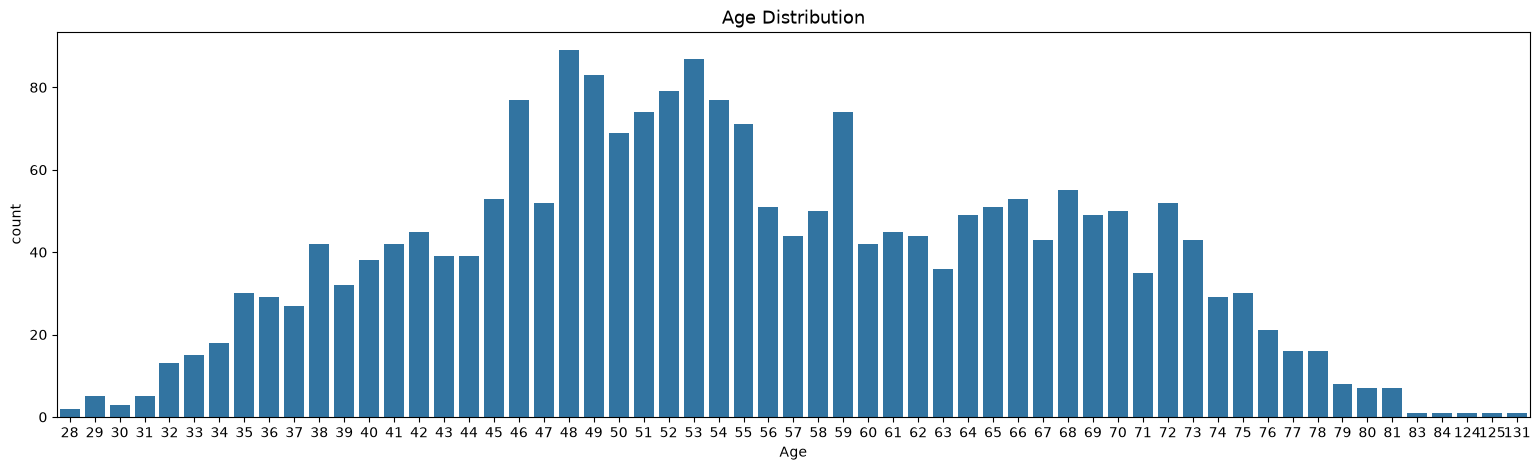

In [10]:
plt.figure(figsize=(19,5))
plt.title('Age Distribution', fontsize=13)
sns.countplot(x='Age',data = df)
plt.show()

<Axes: xlabel='Age'>

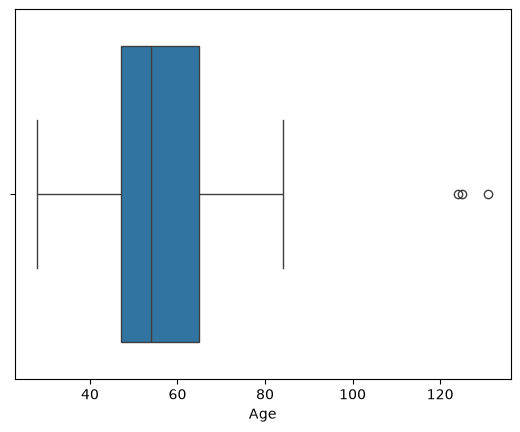

In [11]:
sns.boxplot(x='Age',data=df)

From the above graphs, most customers are between 43 and 55. Also, the minimum age of customers is 24, whereas the maximum is 70.

##Food Distribution

##Top 10 food items sold

##Food Distribution

###Top product categories by total spend

In [12]:
# Product spend columns
product_cols = {
    'MntWines': 'Wines',
    'MntFruits': 'Fruits',
    'MntMeatProducts': 'Meat',
    'MntFishProducts': 'Fish',
    'MntSweetProducts': 'Sweets',
    'MntGoldProds': 'Gold'
}

# Rename for readability
product_spend = df[list(product_cols.keys())].rename(columns=product_cols)
total_spend = product_spend.sum().sort_values(ascending=False)
print(total_spend)

Wines     680816
Meat      373968
Gold       98609
Fish       84057
Sweets     60621
Fruits     58917
dtype: int64


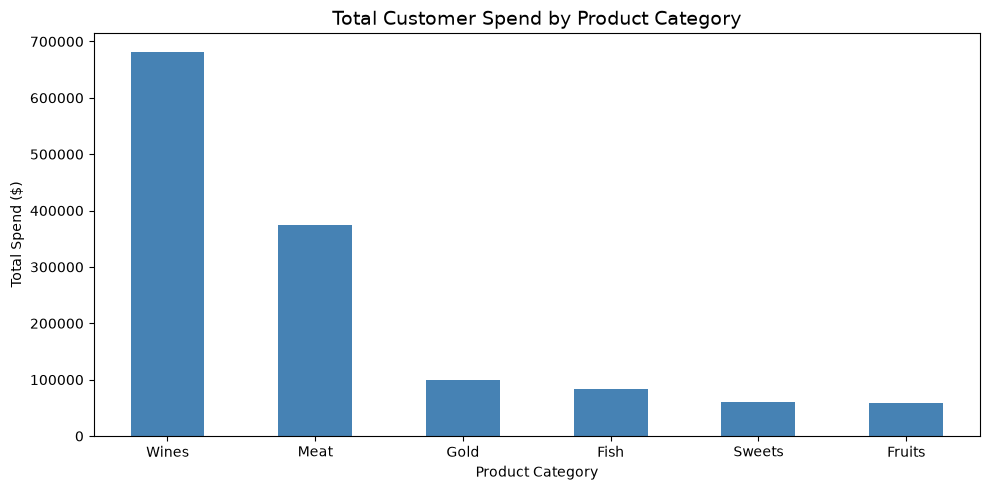

In [13]:
plt.figure(figsize=(10, 5))
total_spend.plot(kind='bar', color='steelblue')
plt.title('Total Customer Spend by Product Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Total Spend ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

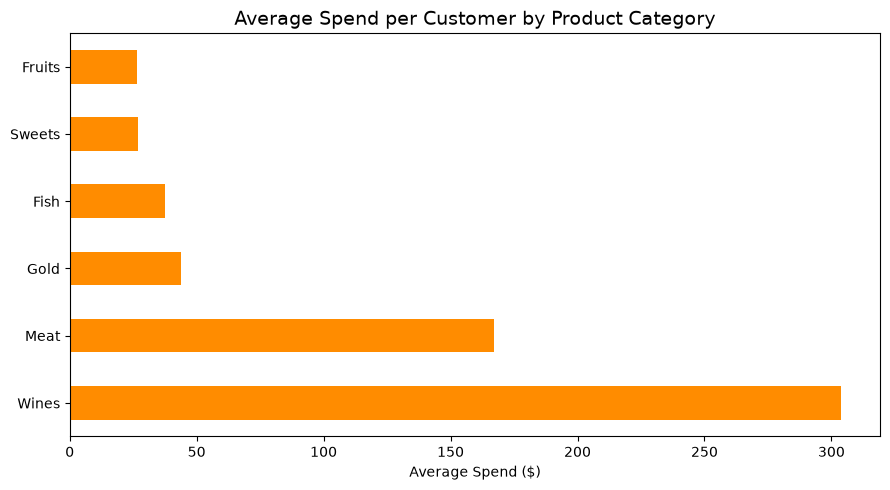

In [14]:
# Average spend per customer by category
avg_spend = product_spend.mean().sort_values(ascending=False)
avg_spend.plot(kind='barh', color='darkorange', figsize=(9, 5))
plt.title('Average Spend per Customer by Product Category', fontsize=14)
plt.xlabel('Average Spend ($)')
plt.tight_layout()
plt.show()

From the data, wines account for the largest share of customer spend, followed by meat products. Gold and fruits are the lowest-spend categories on average.

##Campaign Performance

###Success rate across all 5 campaigns

In [15]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
campaign_names = ['Campaign 1', 'Campaign 2', 'Campaign 3', 'Campaign 4', 'Campaign 5']

campaign_acceptance = df[campaign_cols].sum()
campaign_acceptance.index = campaign_names
total_customers = len(df)

acceptance_rate = (campaign_acceptance / total_customers * 100).round(1)
print("Campaign acceptance rates (%):")
print(acceptance_rate)

Campaign acceptance rates (%):
Campaign 1    6.4
Campaign 2    1.3
Campaign 3    7.3
Campaign 4    7.5
Campaign 5    7.3
dtype: float64


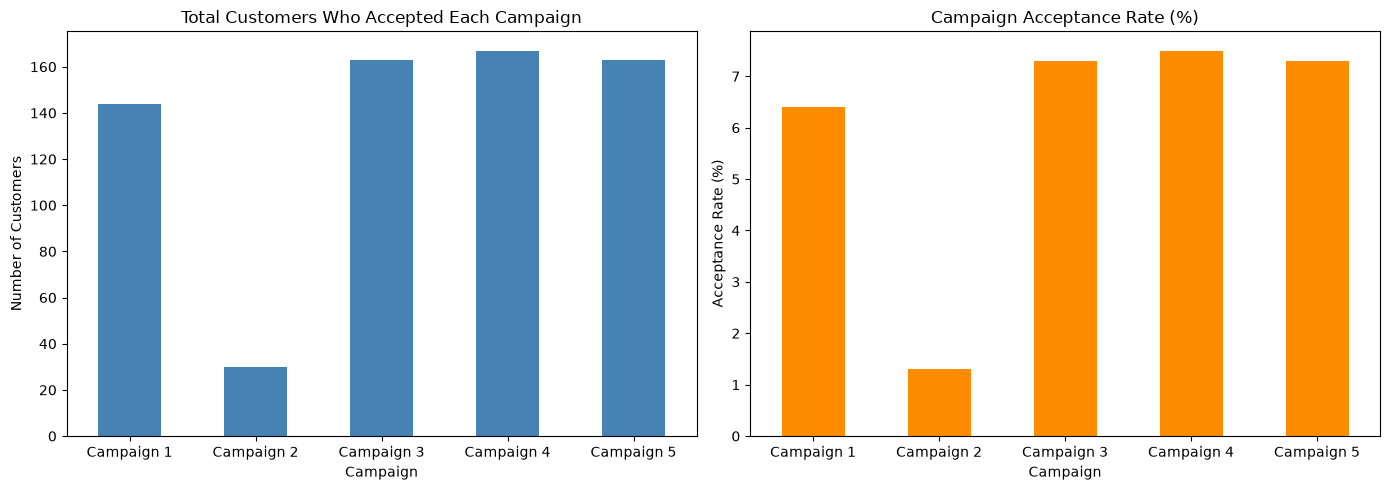

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
campaign_acceptance.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Customers Who Accepted Each Campaign', fontsize=12)
axes[0].set_xlabel('Campaign')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

# Acceptance rates
acceptance_rate.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Campaign Acceptance Rate (%)', fontsize=12)
axes[1].set_xlabel('Campaign')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Campaign acceptance rates vary meaningfully across the 5 campaigns, suggesting that certain messaging strategies or timing windows resonate more strongly with the customer base.

##Channel Performance

In [17]:
channel_cols = {
    'NumWebPurchases': 'Web',
    'NumStorePurchases': 'Store',
    'NumCatalogPurchases': 'Catalog',
    'NumDealsPurchases': 'Deals'
}

channel_data = df[list(channel_cols.keys())].rename(columns=channel_cols)
total_by_channel = channel_data.sum().sort_values(ascending=False)
print(total_by_channel)

Store      12970
Web         9150
Catalog     5963
Deals       5208
dtype: int64


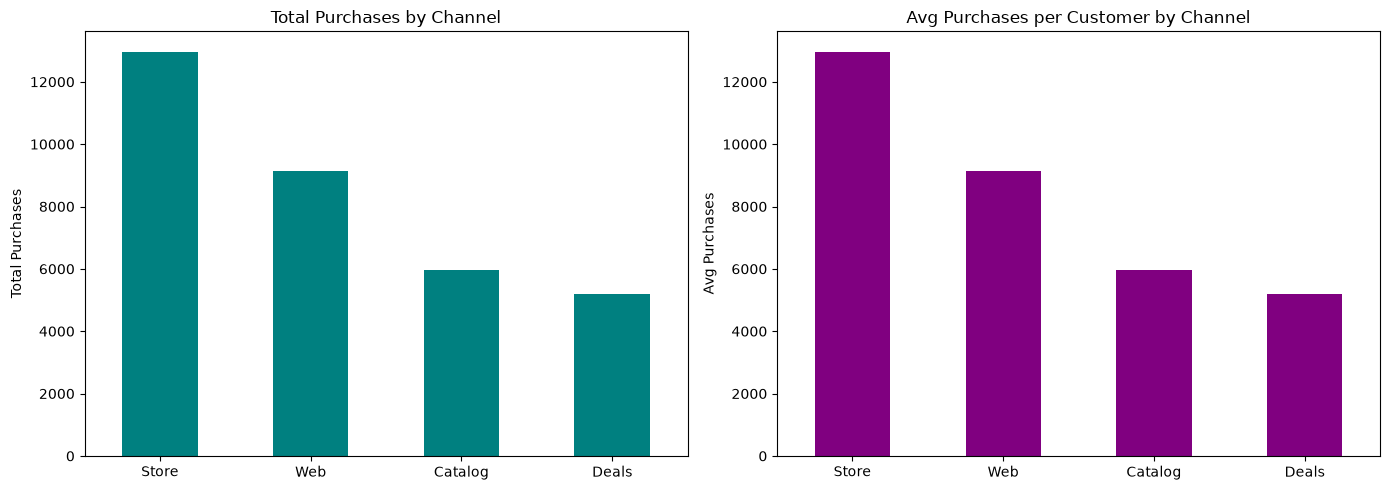

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_by_channel.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Total Purchases by Channel', fontsize=12)
axes[0].set_ylabel('Total Purchases')
axes[0].tick_params(axis='x', rotation=0)

total_by_channel.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Avg Purchases per Customer by Channel', fontsize=12)
axes[1].set_ylabel('Avg Purchases')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Store and web purchases lead all channels by volume. Deal-based and catalog channels show lower engagement, suggesting customers prefer direct purchasing over promotional or catalog-driven conversions.

#Summary

##Key Findings

- Customer age clusters between **43 and 55**, with the youngest at 24 and oldest at 70
- **Wines** are the top-spending product category by a wide margin; **fruits** and **sweets** trail significantly
- Campaign acceptance rates vary across the 5 campaigns, pointing to differences in targeting effectiveness or offer quality
- **Store and web channels** drive the majority of purchase volume; catalog and deals channels see significantly lower engagement
- Higher-income, older customers tend to spend more across all product categories

##Recommendation

Focus re-engagement efforts on web and store channels, where existing purchase behavior is strongest. Campaign messaging should be tailored to the 43-55 demographic, emphasizing premium product categories like wines and meat.
